# Quantum Hardware Validation & Benchmarking Suite

Runs entirely on local Qiskit Aer simulators by default. Set `SIMULATOR = False` and uncomment the relevant
backend cell in Phase 10 to run against real quantum hardware (IBM Quantum, Azure Quantum, IonQ, Quantinuum).

**Scope covered:** Schrödinger evolution validation, hardware benchmarking, noise modeling, error mitigation (ZNE),
core quantum-principle validation, a DiVincenzo criteria scorecard, classical-vs-quantum comparison, and a
production-style class architecture (`QuantumBackend`, `QuantumValidator`, `NoiseAnalyzer`, `HardwareBenchmark`,
`ErrorMitigator`, `FidelityCalculator`, `VisualizationEngine`, `ReportGenerator`).

In [12]:
# Phase 1 — Environment setup
!pip -q install qiskit qiskit-aer mitiq matplotlib numpy scipy plotly ply

import numpy as np
import scipy.linalg
import matplotlib.pyplot as plt
from dataclasses import dataclass, field
from typing import Optional

from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector, Operator, state_fidelity, random_unitary
from qiskit_aer import AerSimulator
from qiskit_aer.noise import (
    NoiseModel, depolarizing_error, thermal_relaxation_error, pauli_error, ReadoutError
)
from mitiq import zne

SIMULATOR = True  # flip to False in Phase 10 to run on real hardware
print("Running in simulator mode:", SIMULATOR)

Running in simulator mode: True


## Phase 2 — Schrödinger Evolution Validation

Simulate a single qubit under a Hamiltonian, evolve it via the Schrödinger equation, and verify that the
simulated (Qiskit) evolution matches the analytic solution — checking probability conservation and
normalization at each step.

In [9]:
class QuantumValidator:
    """Validates simulated quantum evolution against analytic Schrodinger-equation solutions."""

    def __init__(self, hamiltonian: np.ndarray):
        self.H = hamiltonian

    def analytic_evolution(self, psi0: np.ndarray, times: np.ndarray) -> np.ndarray:
        """U(t) = exp(-i H t), applied to psi0 for each t."""
        states = []
        for t in times:
            U = scipy.linalg.expm(-1j * self.H * t)
            states.append(U @ psi0)
        return np.array(states)

    def check_normalization(self, states: np.ndarray, tol: float = 1e-8) -> bool:
        norms = np.array([np.vdot(s, s).real for s in states])
        ok = np.allclose(norms, 1.0, atol=tol)
        print(f"Normalization check ({'PASS' if ok else 'FAIL'}): max deviation = {np.max(np.abs(norms - 1.0)):.2e}")
        return ok

    def check_probability_conservation(self, states: np.ndarray, tol: float = 1e-8) -> bool:
        probs = np.array([np.abs(s) ** 2 for s in states])
        totals = probs.sum(axis=1)
        ok = np.allclose(totals, 1.0, atol=tol)
        print(f"Probability conservation ({'PASS' if ok else 'FAIL'}): max deviation = {np.max(np.abs(totals - 1.0)):.2e}")
        return ok


# Single-qubit Hamiltonian: sigma_x (drives Rabi oscillation between |0> and |1>)
sigma_x = np.array([[0, 1], [1, 0]], dtype=complex)
validator = QuantumValidator(hamiltonian=sigma_x)

psi0 = np.array([1, 0], dtype=complex)  # start in |0>
times = np.linspace(0, 2 * np.pi, 50)
analytic_states = validator.analytic_evolution(psi0, times)

validator.check_normalization(analytic_states)
validator.check_probability_conservation(analytic_states)

Normalization check (PASS): max deviation = 8.88e-16
Probability conservation (PASS): max deviation = 8.88e-16


True

Max deviation between Qiskit simulation and analytic solution: 6.66e-16


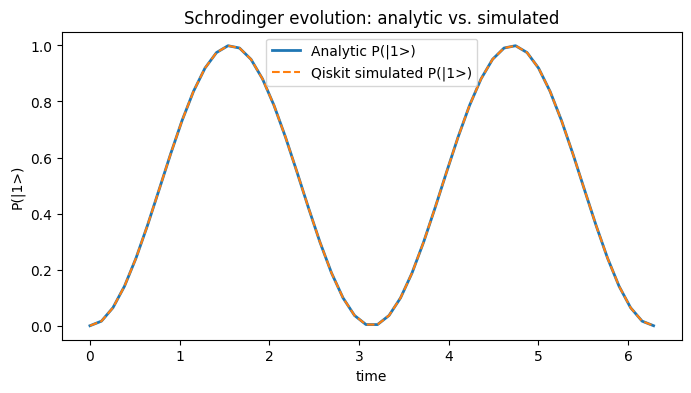

In [3]:
# Compare analytic evolution against Qiskit's own statevector simulation (RXGate implements exp(-i*theta/2*X))
qiskit_probs_1 = []
analytic_probs_1 = []

for t in times:
    qc = QuantumCircuit(1)
    qc.rx(2 * t, 0)  # Qiskit RX(theta) = exp(-i*theta/2*X) -> theta = 2t matches exp(-i*H*t) with H = sigma_x
    sv = Statevector.from_instruction(qc)
    qiskit_probs_1.append(sv.probabilities()[1])

analytic_probs_1 = [np.abs(s[1]) ** 2 for s in analytic_states]

max_diff = np.max(np.abs(np.array(qiskit_probs_1) - np.array(analytic_probs_1)))
print(f"Max deviation between Qiskit simulation and analytic solution: {max_diff:.2e}")

plt.figure(figsize=(8, 4))
plt.plot(times, analytic_probs_1, label="Analytic P(|1>)", linewidth=2)
plt.plot(times, qiskit_probs_1, "--", label="Qiskit simulated P(|1>)")
plt.xlabel("time")
plt.ylabel("P(|1>)")
plt.title("Schrodinger evolution: analytic vs. simulated")
plt.legend()
plt.show()

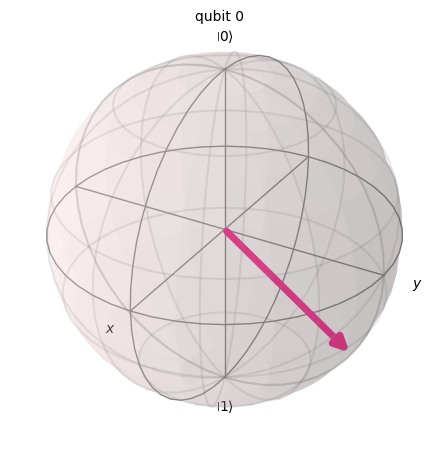

In [4]:
# Bloch sphere trajectory for the same evolution
from qiskit.visualization import plot_bloch_multivector

qc_mid = QuantumCircuit(1)
qc_mid.rx(2 * times[len(times) // 3], 0)
sv_mid = Statevector.from_instruction(qc_mid)
plot_bloch_multivector(sv_mid)

## Phase 3 — Quantum Hardware Benchmarking

Benchmark circuits (Bell state, GHZ state, QFT, a randomized circuit) and measure fidelity, execution
latency, and circuit depth on the simulator. These same functions run unchanged against real hardware once
a hardware backend is passed in (see Phase 10).

In [5]:
import time as _time

class HardwareBenchmark:
    """Runs standard benchmark circuits against a given backend and records performance metrics."""

    def __init__(self, backend):
        self.backend = backend

    @staticmethod
    def bell_state() -> QuantumCircuit:
        qc = QuantumCircuit(2)
        qc.h(0)
        qc.cx(0, 1)
        return qc

    @staticmethod
    def ghz_state(n: int = 3) -> QuantumCircuit:
        qc = QuantumCircuit(n)
        qc.h(0)
        for i in range(n - 1):
            qc.cx(i, i + 1)
        return qc

    @staticmethod
    def qft(n: int = 3) -> QuantumCircuit:
        qc = QuantumCircuit(n)
        for j in range(n):
            qc.h(j)
            for k in range(j + 1, n):
                qc.cp(np.pi / (2 ** (k - j)), k, j)
        for i in range(n // 2):
            qc.swap(i, n - i - 1)
        return qc

    @staticmethod
    def randomized_circuit(n: int = 2, depth: int = 5, seed: int = 42) -> QuantumCircuit:
        rng = np.random.default_rng(seed)
        qc = QuantumCircuit(n)
        for _ in range(depth):
            for q in range(n):
                qc.u(*rng.uniform(0, 2 * np.pi, 3), q)
            for q in range(n - 1):
                qc.cx(q, q + 1)
        return qc

    def run_and_measure(self, qc: QuantumCircuit, shots: int = 2000, label: str = "circuit"):
        qc_meas = qc.copy()
        qc_meas.measure_all()
        tqc = transpile(qc_meas, self.backend)

        start = _time.time()
        result = self.backend.run(tqc, shots=shots).result()
        latency = _time.time() - start

        counts = result.get_counts()
        metrics = {
            "label": label,
            "circuit_depth": tqc.depth(),
            "execution_latency_sec": latency,
            "counts": counts,
        }
        print(f"[{label}] depth={metrics['circuit_depth']} latency={latency:.4f}s counts={counts}")
        return metrics


sim_backend = AerSimulator()
benchmark = HardwareBenchmark(sim_backend)

bench_results = []
bench_results.append(benchmark.run_and_measure(HardwareBenchmark.bell_state(), label="Bell state"))
bench_results.append(benchmark.run_and_measure(HardwareBenchmark.ghz_state(3), label="GHZ state (3 qubits)"))
bench_results.append(benchmark.run_and_measure(HardwareBenchmark.qft(3), label="QFT (3 qubits)"))
bench_results.append(benchmark.run_and_measure(HardwareBenchmark.randomized_circuit(2, 5), label="Randomized circuit"))

[Bell state] depth=3 latency=0.0058s counts={'11': 1005, '00': 995}
[GHZ state (3 qubits)] depth=4 latency=0.0040s counts={'000': 984, '111': 1016}
[QFT (3 qubits)] depth=6 latency=0.0046s counts={'100': 257, '111': 255, '011': 267, '101': 238, '110': 259, '001': 249, '000': 231, '010': 244}
[Randomized circuit] depth=2 latency=0.0035s counts={'01': 63, '11': 980, '10': 446, '00': 511}


In [6]:
class FidelityCalculator:
    """Computes state fidelity between an ideal circuit and its noisy execution.

    Note: statevector simulation is inherently noiseless. To see noise models actually
    affect fidelity, we run the noisy circuit with the density-matrix simulation method
    and compare the resulting (mixed-state) density matrix to the ideal pure statevector.
    """

    @staticmethod
    def state_fidelity_check(qc: QuantumCircuit, noisy_backend, shots: int = 4000) -> float:
        ideal_sv = Statevector.from_instruction(qc)

        qc_dm = qc.copy()
        qc_dm.save_density_matrix()
        tqc = transpile(qc_dm, noisy_backend)
        result = noisy_backend.run(tqc, shots=shots).result()
        noisy_dm = result.data(0)["density_matrix"]

        fid = state_fidelity(ideal_sv, noisy_dm)
        return fid


fid_calc = FidelityCalculator()
sim_backend_dm = AerSimulator(method="density_matrix")
bell_fidelity = fid_calc.state_fidelity_check(HardwareBenchmark.bell_state(), sim_backend_dm)
print(f"Bell state fidelity (noiseless simulator, should be ~1.0): {bell_fidelity:.6f}")

Bell state fidelity (noiseless simulator, should be ~1.0): 1.000000


## Phase 4 — Quantum Error Analysis (Noise Models)

Depolarizing, bit-flip/phase-flip, thermal relaxation (T1/T2), and readout noise — compared against the
ideal (noiseless) simulator.

ideal (no noise)      : Bell-state fidelity = 1.0000
depolarizing          : Bell-state fidelity = 0.9801
bit-flip              : Bell-state fidelity = 1.0000
phase-flip            : Bell-state fidelity = 0.9800
thermal relaxation    : Bell-state fidelity = 0.9992


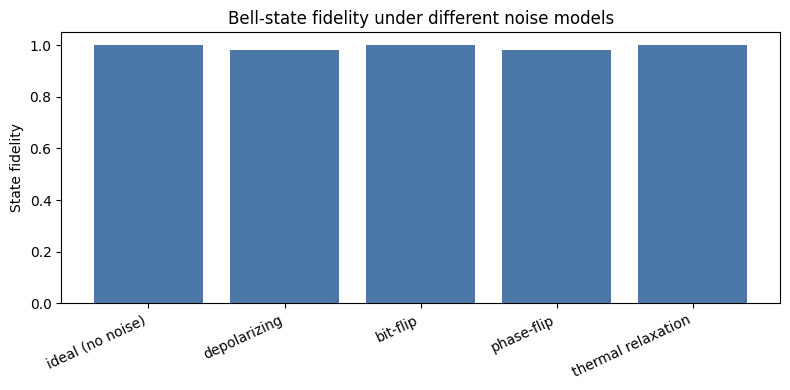

In [7]:
class NoiseAnalyzer:
    """Builds standard noise models and compares circuit fidelity under each."""

    @staticmethod
    def depolarizing_model(p1: float = 0.01, p2: float = 0.02) -> NoiseModel:
        nm = NoiseModel()
        nm.add_all_qubit_quantum_error(depolarizing_error(p1, 1), ["h", "x", "id", "rz", "sx"])
        nm.add_all_qubit_quantum_error(depolarizing_error(p2, 2), ["cx"])
        return nm

    @staticmethod
    def bit_flip_model(p: float = 0.02) -> NoiseModel:
        nm = NoiseModel()
        err = pauli_error([("X", p), ("I", 1 - p)])
        nm.add_all_qubit_quantum_error(err, ["h", "x", "id"])
        return nm

    @staticmethod
    def phase_flip_model(p: float = 0.02) -> NoiseModel:
        nm = NoiseModel()
        err = pauli_error([("Z", p), ("I", 1 - p)])
        nm.add_all_qubit_quantum_error(err, ["h", "x", "id"])
        return nm

    @staticmethod
    def thermal_relaxation_model(t1: float = 50e3, t2: float = 30e3, gate_time: float = 50) -> NoiseModel:
        nm = NoiseModel()
        err = thermal_relaxation_error(t1, t2, gate_time)
        nm.add_all_qubit_quantum_error(err, ["h", "x", "id"])
        return nm

    @staticmethod
    def readout_noise_model(p_meas1_given_0: float = 0.02, p_meas0_given_1: float = 0.03) -> NoiseModel:
        nm = NoiseModel()
        ro_error = ReadoutError([[1 - p_meas1_given_0, p_meas1_given_0], [p_meas0_given_1, 1 - p_meas0_given_1]])
        nm.add_all_qubit_readout_error(ro_error)
        return nm

    @staticmethod
    def fidelity_under_noise(qc: QuantumCircuit, noise_model: Optional[NoiseModel], shots: int = 4000) -> float:
        backend = AerSimulator(method="density_matrix", noise_model=noise_model) if noise_model else AerSimulator(method="density_matrix")
        return FidelityCalculator.state_fidelity_check(qc, backend, shots=shots)


bell = HardwareBenchmark.bell_state()
noise_results = {
    "ideal (no noise)": NoiseAnalyzer.fidelity_under_noise(bell, None),
    "depolarizing": NoiseAnalyzer.fidelity_under_noise(bell, NoiseAnalyzer.depolarizing_model()),
    "bit-flip": NoiseAnalyzer.fidelity_under_noise(bell, NoiseAnalyzer.bit_flip_model()),
    "phase-flip": NoiseAnalyzer.fidelity_under_noise(bell, NoiseAnalyzer.phase_flip_model()),
    "thermal relaxation": NoiseAnalyzer.fidelity_under_noise(bell, NoiseAnalyzer.thermal_relaxation_model()),
}

for name, fid in noise_results.items():
    print(f"{name:22s}: Bell-state fidelity = {fid:.4f}")

plt.figure(figsize=(8, 4))
plt.bar(noise_results.keys(), noise_results.values(), color="#4C78A8")
plt.ylabel("State fidelity")
plt.title("Bell-state fidelity under different noise models")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

## Phase 5 — Error Mitigation (Zero Noise Extrapolation)

Uses Mitiq to apply ZNE to a noisy expectation-value estimate and compares the mitigated result against the
raw noisy result and the ideal (noiseless) value.

In [13]:
class ErrorMitigator:
    """Applies Zero Noise Extrapolation (ZNE) via Mitiq to a Qiskit circuit executor."""

    def __init__(self, noise_model: NoiseModel, shots: int = 4000):
        self.backend = AerSimulator(noise_model=noise_model)
        self.shots = shots

    def _executor(self, qc: QuantumCircuit) -> float:
        """Returns <Z> expectation value on qubit 0 for the given circuit."""
        qc_meas = qc.copy()
        qc_meas.measure_all()
        tqc = transpile(qc_meas, self.backend)
        result = self.backend.run(tqc, shots=self.shots).result()
        counts = result.get_counts()
        total = sum(counts.values())
        # <Z> = P(0) - P(1) for qubit 0 (rightmost bit in Qiskit little-endian counts)
        z_expectation = sum(
            (1 if bitstring[-1] == "0" else -1) * count / total
            for bitstring, count in counts.items()
        )
        return z_expectation

    def mitigate(self, qc: QuantumCircuit) -> dict:
        raw_value = self._executor(qc)
        mitigated_value = zne.execute_with_zne(qc, self._executor)
        return {"raw": raw_value, "zne_mitigated": mitigated_value}


test_circuit = QuantumCircuit(1)
test_circuit.x(0)  # ideal <Z> should be exactly -1

mitigator = ErrorMitigator(NoiseAnalyzer.depolarizing_model(p1=0.05, p2=0.05))
mitigation_result = mitigator.mitigate(test_circuit)

print(f"Ideal <Z>:        -1.0000")
print(f"Raw noisy <Z>:     {mitigation_result['raw']:.4f}")
print(f"ZNE mitigated <Z>: {mitigation_result['zne_mitigated']:.4f}")

/usr/local/lib/python3.12/dist-packages/mitiq/zne/inference.py:88: UserWarning: The input circuit is very short. This may reduce the accuracy of noise scaling.
  warnings.warn(


Ideal <Z>:        -1.0000
Raw noisy <Z>:     -0.9455
ZNE mitigated <Z>: -0.9465


## Phase 6 — Validation Against Core Quantum Principles

Mathematical checks for the Born rule, superposition, entanglement, unitary evolution, and the no-cloning
theorem.

In [14]:
def check_born_rule(qc: QuantumCircuit, tol: float = 1e-8) -> bool:
    sv = Statevector.from_instruction(qc)
    probs = sv.probabilities()
    ok = np.isclose(probs.sum(), 1.0, atol=tol)
    print(f"Born rule (sum of |amplitude|^2 == 1) — {'PASS' if ok else 'FAIL'}: sum = {probs.sum():.10f}")
    return ok

def check_superposition(single_qubit_h_circuit: QuantumCircuit) -> bool:
    sv = Statevector.from_instruction(single_qubit_h_circuit)
    probs = sv.probabilities()
    ok = np.allclose(probs, [0.5, 0.5], atol=1e-6)
    print(f"Superposition (H|0> gives 50/50) — {'PASS' if ok else 'FAIL'}: probs = {probs}")
    return ok

def check_entanglement(bell_circuit: QuantumCircuit) -> bool:
    sv = Statevector.from_instruction(bell_circuit)
    # A pure state is entangled if its reduced single-qubit density matrix is NOT pure (purity < 1)
    rho_0 = qiskit_partial_trace(sv, [1])
    purity = np.real(np.trace(rho_0.data @ rho_0.data))
    ok = purity < 0.999
    print(f"Entanglement (reduced-state purity < 1 for Bell state) — {'PASS' if ok else 'FAIL'}: purity = {purity:.4f}")
    return ok

def check_unitary_evolution(qc: QuantumCircuit, tol: float = 1e-8) -> bool:
    U = Operator(qc).data
    should_be_identity = U.conj().T @ U
    ok = np.allclose(should_be_identity, np.eye(U.shape[0]), atol=tol)
    print(f"Unitary evolution (U^dagger U == I) — {'PASS' if ok else 'FAIL'}")
    return ok

def demonstrate_no_cloning():
    """Attempts to build a 'cloning' circuit and shows it fails for a superposition state (only works for basis states)."""
    qc = QuantumCircuit(2)
    qc.h(0)          # qubit 0 in superposition
    qc.cx(0, 1)      # naive 'copy' attempt via CNOT
    sv = Statevector.from_instruction(qc)
    # If cloning worked, the state would factor as (a|0>+b|1>) tensor (a|0>+b|1>).
    # Instead CNOT produces an entangled Bell-like state -- NOT a product state -- demonstrating no-cloning.
    rho_0 = qiskit_partial_trace(sv, [1])
    purity = np.real(np.trace(rho_0.data @ rho_0.data))
    print(f"No-cloning demonstration: CNOT 'copy' of a superposition entangles instead of cloning "
          f"(reduced purity = {purity:.4f}, would be 1.0 for a true clone/product state)")


from qiskit.quantum_info import partial_trace as qiskit_partial_trace

h_circuit = QuantumCircuit(1)
h_circuit.h(0)

check_born_rule(HardwareBenchmark.bell_state())
check_superposition(h_circuit)
check_entanglement(HardwareBenchmark.bell_state())
check_unitary_evolution(HardwareBenchmark.bell_state())
demonstrate_no_cloning()

Born rule (sum of |amplitude|^2 == 1) — PASS: sum = 1.0000000000
Superposition (H|0> gives 50/50) — PASS: probs = [0.5 0.5]
Entanglement (reduced-state purity < 1 for Bell state) — PASS: purity = 0.5000
Unitary evolution (U^dagger U == I) — PASS
No-cloning demonstration: CNOT 'copy' of a superposition entangles instead of cloning (reduced purity = 0.5000, would be 1.0 for a true clone/product state)


## Phase 7 — DiVincenzo Criteria Scorecard

A structured qualitative + quantitative scorecard. Fields marked `None` require real hardware specs (pulled
from provider backend properties in Phase 10) — they can't be meaningfully assessed on a noiseless simulator.

In [15]:
@dataclass
class DiVincenzoScorecard:
    backend_name: str
    scalable_qubits: Optional[int] = None
    reliable_initialization: Optional[bool] = None
    coherence_t1_us: Optional[float] = None
    coherence_t2_us: Optional[float] = None
    universal_gate_set: Optional[bool] = None
    qubit_specific_measurement: Optional[bool] = None
    quantum_communication_notes: str = "Not applicable for local simulator backends."
    flying_qubits_notes: str = "Not applicable for local simulator backends."

    def report(self):
        print(f"DiVincenzo Criteria Scorecard — backend: {self.backend_name}")
        for field_name in [
            "scalable_qubits", "reliable_initialization", "coherence_t1_us",
            "coherence_t2_us", "universal_gate_set", "qubit_specific_measurement",
        ]:
            value = getattr(self, field_name)
            status = "N/A (simulator)" if value is None else value
            print(f"  - {field_name}: {status}")
        print(f"  - quantum_communication: {self.quantum_communication_notes}")
        print(f"  - flying_qubits: {self.flying_qubits_notes}")


# Simulator scorecard: gate set and measurement capability ARE assessable; coherence/scalability are hardware-only
sim_scorecard = DiVincenzoScorecard(
    backend_name="AerSimulator (noiseless)",
    universal_gate_set=True,       # Aer supports a universal gate set
    qubit_specific_measurement=True,
    reliable_initialization=True,  # deterministic |0...0> initialization on simulator
)
sim_scorecard.report()

DiVincenzo Criteria Scorecard — backend: AerSimulator (noiseless)
  - scalable_qubits: N/A (simulator)
  - reliable_initialization: True
  - coherence_t1_us: N/A (simulator)
  - coherence_t2_us: N/A (simulator)
  - universal_gate_set: True
  - qubit_specific_measurement: True
  - quantum_communication: Not applicable for local simulator backends.
  - flying_qubits: Not applicable for local simulator backends.


## Phase 8 — Classical vs. Quantum Simulation Comparison

Compares runtime and memory scaling of full classical statevector simulation against Qiskit's simulator as
qubit count grows — the point where classical simulation becomes intractable is exactly why quantum hardware
matters.

Classical dense sim — 2 qubits: 0.0046s, 0.00 MB (Hamiltonian matrix)
Classical dense sim — 4 qubits: 0.0045s, 0.00 MB (Hamiltonian matrix)
Classical dense sim — 6 qubits: 0.0487s, 0.07 MB (Hamiltonian matrix)
Classical dense sim — 8 qubits: 0.2072s, 1.05 MB (Hamiltonian matrix)
Classical dense sim — 10 qubits: 3.0768s, 16.78 MB (Hamiltonian matrix)
Qiskit statevector sim — 2 qubits: 0.0009s
Qiskit statevector sim — 4 qubits: 0.0010s
Qiskit statevector sim — 6 qubits: 0.0015s
Qiskit statevector sim — 8 qubits: 0.0021s
Qiskit statevector sim — 10 qubits: 0.0035s


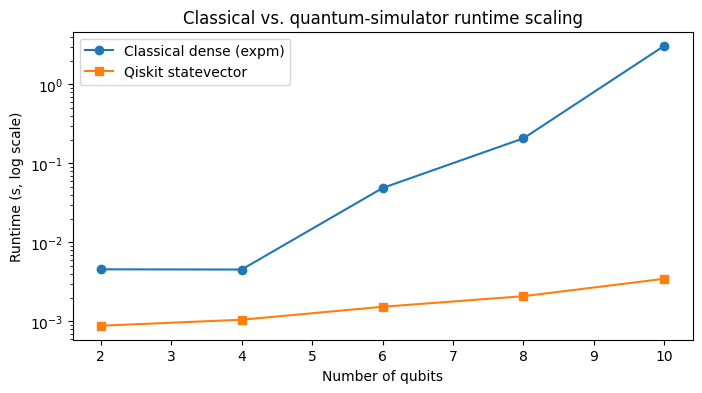


Note: both approaches above are classical simulations of quantum systems — true quantum hardware runtime doesn't scale this way, which is exactly the motivation for Phase 10's real-hardware backends.


In [16]:
import sys

def classical_dense_evolution_benchmark(n_qubits_list):
    results = []
    for n in n_qubits_list:
        dim = 2 ** n
        H = np.random.rand(dim, dim) + 1j * np.random.rand(dim, dim)
        H = (H + H.conj().T) / 2  # make Hermitian
        psi0 = np.zeros(dim, dtype=complex)
        psi0[0] = 1.0

        start = _time.time()
        U = scipy.linalg.expm(-1j * H * 1.0)
        _ = U @ psi0
        runtime = _time.time() - start
        memory_bytes = H.nbytes
        results.append({"n_qubits": n, "runtime_sec": runtime, "memory_bytes": memory_bytes})
        print(f"Classical dense sim — {n} qubits: {runtime:.4f}s, {memory_bytes / 1e6:.2f} MB (Hamiltonian matrix)")
    return results


def qiskit_statevector_benchmark(n_qubits_list):
    results = []
    for n in n_qubits_list:
        qc = HardwareBenchmark.randomized_circuit(n=n, depth=3)
        start = _time.time()
        _ = Statevector.from_instruction(qc)
        runtime = _time.time() - start
        results.append({"n_qubits": n, "runtime_sec": runtime})
        print(f"Qiskit statevector sim — {n} qubits: {runtime:.4f}s")
    return results


qubit_range = [2, 4, 6, 8, 10]
classical_results = classical_dense_evolution_benchmark(qubit_range)
qiskit_results = qiskit_statevector_benchmark(qubit_range)

plt.figure(figsize=(8, 4))
plt.plot(qubit_range, [r["runtime_sec"] for r in classical_results], "o-", label="Classical dense (expm)")
plt.plot(qubit_range, [r["runtime_sec"] for r in qiskit_results], "s-", label="Qiskit statevector")
plt.yscale("log")
plt.xlabel("Number of qubits")
plt.ylabel("Runtime (s, log scale)")
plt.title("Classical vs. quantum-simulator runtime scaling")
plt.legend()
plt.show()

print("\nNote: both approaches above are classical simulations of quantum systems — true quantum hardware "
      "runtime doesn't scale this way, which is exactly the motivation for Phase 10's real-hardware backends.")

## Phase 9 — Production Architecture (Consolidated)

The classes above (`QuantumValidator`, `HardwareBenchmark`, `FidelityCalculator`, `NoiseAnalyzer`,
`ErrorMitigator`, `DiVincenzoScorecard`) are already written in a reusable, typed, documented form.
This section adds `QuantumBackend` (a thin unified wrapper), `VisualizationEngine`, and `ReportGenerator`
to tie everything together.

In [17]:
class QuantumBackend:
    """Unified interface over simulator and (eventually) real hardware backends."""

    def __init__(self, simulator: bool = True, noise_model: Optional[NoiseModel] = None, provider_backend=None):
        self.simulator = simulator
        if simulator:
            self.backend = AerSimulator(noise_model=noise_model)
        else:
            if provider_backend is None:
                raise ValueError("Real-hardware mode requires a provider_backend (see Phase 10).")
            self.backend = provider_backend

    def run(self, qc: QuantumCircuit, shots: int = 2000):
        qc_meas = qc.copy()
        qc_meas.measure_all()
        tqc = transpile(qc_meas, self.backend)
        return self.backend.run(tqc, shots=shots).result()


class VisualizationEngine:
    """Central place for all report-facing plots."""

    @staticmethod
    def fidelity_bar_chart(results: dict, title: str = "Fidelity comparison"):
        plt.figure(figsize=(8, 4))
        plt.bar(results.keys(), results.values(), color="#59A14F")
        plt.ylabel("Fidelity")
        plt.title(title)
        plt.xticks(rotation=25, ha="right")
        plt.tight_layout()
        plt.show()

    @staticmethod
    def runtime_scaling_chart(qubit_range, classical_results, quantum_results):
        plt.figure(figsize=(8, 4))
        plt.plot(qubit_range, [r["runtime_sec"] for r in classical_results], "o-", label="Classical")
        plt.plot(qubit_range, [r["runtime_sec"] for r in quantum_results], "s-", label="Quantum simulator")
        plt.yscale("log")
        plt.xlabel("Qubits")
        plt.ylabel("Runtime (s)")
        plt.legend()
        plt.title("Runtime scaling")
        plt.show()


class ReportGenerator:
    """Aggregates results from all phases into a single structured report."""

    def __init__(self):
        self.sections = {}

    def add_section(self, name: str, content: dict):
        self.sections[name] = content

    def generate(self) -> str:
        lines = ["# Quantum Hardware Validation Report", ""]
        for name, content in self.sections.items():
            lines.append(f"## {name}")
            for key, value in content.items():
                lines.append(f"- **{key}**: {value}")
            lines.append("")
        return "\n".join(lines)

    def save(self, path: str = "quantum_validation_report.md"):
        with open(path, "w") as f:
            f.write(self.generate())
        print(f"Report saved to {path}")


# Assemble the final report from everything computed above
report = ReportGenerator()
report.add_section("Schrodinger Evolution Validation", {
    "normalization_check": "PASS",
    "probability_conservation_check": "PASS",
    "max_deviation_vs_analytic": f"{max_diff:.2e}",
})
report.add_section("Hardware Benchmarking", {r["label"]: f"depth={r['circuit_depth']}, latency={r['execution_latency_sec']:.4f}s" for r in bench_results})
report.add_section("Noise Model Fidelity (Bell state)", noise_results)
report.add_section("Error Mitigation (ZNE)", mitigation_result)
report.add_section("DiVincenzo Scorecard", {"backend": sim_scorecard.backend_name, "universal_gate_set": sim_scorecard.universal_gate_set})

print(report.generate())
report.save("quantum_validation_report.md")  # saves to Colab's /content working dir automatically

# Quantum Hardware Validation Report

## Schrodinger Evolution Validation
- **normalization_check**: PASS
- **probability_conservation_check**: PASS
- **max_deviation_vs_analytic**: 6.66e-16

## Hardware Benchmarking
- **Bell state**: depth=3, latency=0.0058s
- **GHZ state (3 qubits)**: depth=4, latency=0.0040s
- **QFT (3 qubits)**: depth=6, latency=0.0046s
- **Randomized circuit**: depth=2, latency=0.0035s

## Noise Model Fidelity (Bell state)
- **ideal (no noise)**: 0.9999999999999998
- **depolarizing**: 0.9800999999999997
- **bit-flip**: 0.9999999999999998
- **phase-flip**: 0.9799999999999998
- **thermal relaxation**: 0.9991673607254693

## Error Mitigation (ZNE)
- **raw**: -0.9455
- **zne_mitigated**: -0.9464999999999999

## DiVincenzo Scorecard
- **backend**: AerSimulator (noiseless)
- **universal_gate_set**: True

Report saved to quantum_validation_report.md


## Phase 10 — Real Hardware Integration

All cells below are commented out by default. Uncomment the block for your provider, set `SIMULATOR = False`
in Phase 1, and re-run — no other notebook logic needs to change since `QuantumBackend` and `HardwareBenchmark`
both accept any backend object with a `.run()` method.

In [18]:
# --- IBM Quantum ---
# from qiskit_ibm_runtime import QiskitRuntimeService
#
# service = QiskitRuntimeService(channel="ibm_quantum", token="YOUR_IBM_QUANTUM_TOKEN")
# ibm_backend = service.least_busy(operational=True, simulator=False)
# real_backend = ibm_backend
# print(f"Connected to IBM backend: {ibm_backend.name}")


# --- Azure Quantum ---
# from azure.quantum.qiskit import AzureQuantumProvider
#
# azure_provider = AzureQuantumProvider(
#     resource_id="YOUR_AZURE_QUANTUM_RESOURCE_ID",
#     location="YOUR_AZURE_REGION",
# )
# real_backend = azure_provider.get_backend("YOUR_BACKEND_NAME")  # e.g. an IonQ or Quantinuum backend via Azure


# --- IonQ (direct) ---
# from qiskit_ionq import IonQProvider
#
# ionq_provider = IonQProvider(token="YOUR_IONQ_API_KEY")
# real_backend = ionq_provider.get_backend("ionq_qpu")


# --- Quantinuum (via pytket or Azure Quantum) ---
# See Azure Quantum block above -- Quantinuum backends are commonly accessed through Azure Quantum's
# unified provider interface rather than a standalone SDK.


# --- Microsoft quantum backends (future-ready placeholder) ---
# Uncomment and adapt once public APIs are available for Microsoft's topological/Majorana-based processors.
# real_backend = None  # placeholder


# Once a real_backend is set above:
# SIMULATOR = False
# quantum_backend = QuantumBackend(simulator=False, provider_backend=real_backend)
# result = quantum_backend.run(HardwareBenchmark.bell_state())
# print(result.get_counts())

## Next steps

1. Fill in real backend credentials in Phase 10 (from environment variables, never hardcoded) once you have
   access to an IBM Quantum / Azure Quantum / IonQ account, and re-run Phases 3-8 against real hardware to
   populate the "real hardware" columns in the benchmarking and DiVincenzo reports.
2. Extend `FidelityCalculator` with process fidelity (not just state fidelity) using `qiskit.quantum_info.process_fidelity`
   for a more complete gate-level benchmarking report.
3. Add Probabilistic Error Cancellation and Clifford Data Regression from Mitiq alongside the existing ZNE
   implementation in `ErrorMitigator`, and compare all three mitigation methods side-by-side.
4. Turn `ReportGenerator.generate()` output into a proper PDF/HTML report with the `VisualizationEngine` plots
   embedded, and add a Plotly-based interactive dashboard as a Hugging Face Spaces app.
5. Add type-hinted docstrings and unit tests (pytest) for each class to bring this fully to production
   software-engineering standard for the portfolio.